In [26]:
from pathlib import Path
import sys
import os

%load_ext autoreload
%autoreload 2

dir = Path().resolve().parents[1]

if dir not in sys.path:
    print("directory path is not in the system path")
    sys.path.append(str(dir))
    print("adding directory...")
else:
    print("Directory already exists in the system path")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
directory path is not in the system path
adding directory...


In [27]:
from nn import Unet1D, Returns, RMSELoss, EarlyStopping
from scripts import train, evaluate
from utils import log_transform
import torch
from torch.utils.data import DataLoader
import yfinance as yf
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt

In [28]:
ticker = "^GSPC"
start_interval = "2010-01-01"
end_interval = "2026-01-01"
interval = "1d"

raw_snp500 = torch.tensor(yf.Ticker(ticker).history(start=start_interval, end=end_interval, interval=interval)["Close"].to_numpy())

In [29]:
len(raw_snp500)

4024

In [30]:
raw_snp500[0:10]

tensor([1132.9900, 1136.5200, 1137.1400, 1141.6899, 1144.9800, 1146.9800,
        1136.2200, 1145.6801, 1148.4600, 1136.0300], dtype=torch.float64)

In [31]:
split = math.ceil(len(raw_snp500) * 0.2)
val_split = len(raw_snp500) - split * 2
test_split = len(raw_snp500) - split
train_raw_snp500, val_raw_snp500, test_raw_snp500 = raw_snp500[:val_split], raw_snp500[val_split:test_split], raw_snp500[test_split:]

window_size = 256

train_data = Returns(
  raw_returns=train_raw_snp500,
  window_size=window_size,
  transform=log_transform,
  standard=True
)
val_data = Returns(
  raw_returns=val_raw_snp500,
  window_size=window_size,
  transform=log_transform,
  standard=True
)
test_data = Returns(
  raw_returns=test_raw_snp500,
  window_size=window_size,
  transform=log_transform,
  standard=True
)

len(train_data), len(val_data), len(test_data)

(2158, 549, 549)

In [32]:
train_data[100]

tensor([[-1.3687e+00, -1.8870e+00,  2.6787e+00,  3.8977e-01, -3.7743e+00,
         -1.4937e+00,  1.1225e+00, -6.7654e-01,  3.0588e+00,  4.2463e-01,
         -2.3380e-01,  2.4344e+00, -1.0052e-01,  9.5448e-02,  9.9078e-02,
         -4.5319e-01, -1.7684e+00, -3.5998e-01, -1.8478e+00,  2.6314e-01,
         -2.5829e-01, -3.4002e+00, -1.1248e+00, -3.8725e-01, -5.3944e-01,
          5.2853e-01,  3.2475e+00,  9.5749e-01,  7.2398e-01,  3.6858e-02,
          1.5857e+00, -5.7784e-02,  8.6195e-02, -3.1587e+00,  5.9456e-01,
          1.1689e+00, -1.4167e+00,  2.3322e+00,  8.3147e-01,  1.1461e+00,
         -1.5317e-01, -7.8172e-01, -4.8550e-01, -3.4470e-02,  2.2810e+00,
         -5.5378e-01,  6.0188e-01, -1.7656e-01, -4.3684e-01,  5.4168e-01,
         -6.7930e-01, -3.0884e+00, -6.1619e-01, -4.7104e-01, -2.8409e-02,
          1.2506e+00,  1.1670e-01, -1.8621e+00, -4.3245e-01, -4.7283e-01,
         -1.5997e+00,  3.0884e-01, -8.6364e-01,  1.7125e+00, -1.6220e+00,
          4.0619e-04,  3.0586e+00,  9.

In [33]:
train_dataloader = DataLoader(train_data, batch_size=32, shuffle=True, drop_last=True)
val_dataloader = DataLoader(val_data, batch_size=32, shuffle=True, drop_last=True)
test_dataloader = DataLoader(test_data, batch_size=32, shuffle=True, drop_last=True)

next(iter(train_dataloader)).size()

torch.Size([32, 1, 256])

In [34]:
len(train_dataloader.dataset)

2158

In [35]:
device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)
torch.cuda.manual_seed(42)
device

'cpu'

In [36]:
betas = torch.linspace(1e-4, 2e-2, 1000)
type(1 - betas)

torch.Tensor

In [47]:
encoder_in_channels = [1, 4, 8, 16]
encoder_out_channels = [4, 8, 16, 32]
decoder_in_channels = [32, 16, 8, 4]
decoder_out_channels = [16, 8, 4, 1]
attn_res = 16
n_res_block = 2
T = 1000
num_heads = 4
betas = torch.linspace(1e-4, 2e-2, T)
alpha_hats = torch.cumprod(
  input=1-betas,
  dim=0,
  dtype=torch.float32
)

model = Unet1D(
  attn_res=attn_res,
  n_res_block=n_res_block,
  encoder_in_channels=encoder_in_channels,
  encoder_out_channels=encoder_out_channels,
  decoder_in_channels=decoder_in_channels,
  decoder_out_channels=decoder_out_channels,
  T=T,
  num_heads=num_heads
)

In [48]:
dir = Path().resolve().parents[1]
save_path = dir / "models"


In [49]:
loss_fn = RMSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
  optimizer=optimizer,
  mode='min',
  factor=0.4,
  patience=2,
  threshold=1e-4
)

early_stop = EarlyStopping(
  model=model,
  save_path=save_path,
  patience=10,
  delta=0,
  file_name="model_v0.pth",
  verbose=True
)

In [50]:
train_result = train(
  train_data=train_dataloader,
  val_data=val_dataloader,
  optimizer=optimizer,
  loss_fn=loss_fn,
  epochs=100,
  alpha_hats=alpha_hats,
  model=model,
  scheduler=scheduler,
  early_stopping=early_stop,
  device=device,
  T=T
)

  1%|          | 1/100 [00:06<11:09,  6.77s/it]

Epoch : 0 | train_loss : 1.22 | val_loss : 0.83
New best model found. Current loss: 0.8289334528586444
Current LR:  [0.001]


  2%|▏         | 2/100 [00:12<09:53,  6.05s/it]

Epoch : 1 | train_loss : 0.70 | val_loss : 0.59
New best model found. Current loss: 0.5938977932228762
Current LR:  [0.001]


  3%|▎         | 3/100 [00:17<09:25,  5.83s/it]

...

Epoch : 14 | train_loss : 0.57 | val_loss : 0.55
Current LR:  [0.00016]


 16%|█▌        | 16/100 [01:37<09:07,  6.52s/it]

Epoch : 15 | train_loss : 0.57 | val_loss : 0.54
Current LR:  [6.400000000000001e-05]


 16%|█▌        | 16/100 [01:42<08:58,  6.41s/it]

Epoch : 16 | train_loss : 0.57 | val_loss : 0.54
Stopping early as no improvement has been observed
Best Loss 0.5121316752013039
Overwriting an existing model...
The best model has been saved
Early stopping at epoch : 16
Total training time: 102.63221478462219 seconds


In [51]:
test_result = evaluate(
  test_dataloader,
  loss_fn=loss_fn,
  model=model,
  alpha_hats=alpha_hats,
  T=T,
  device=device
)
test_result

0.5746392134357902

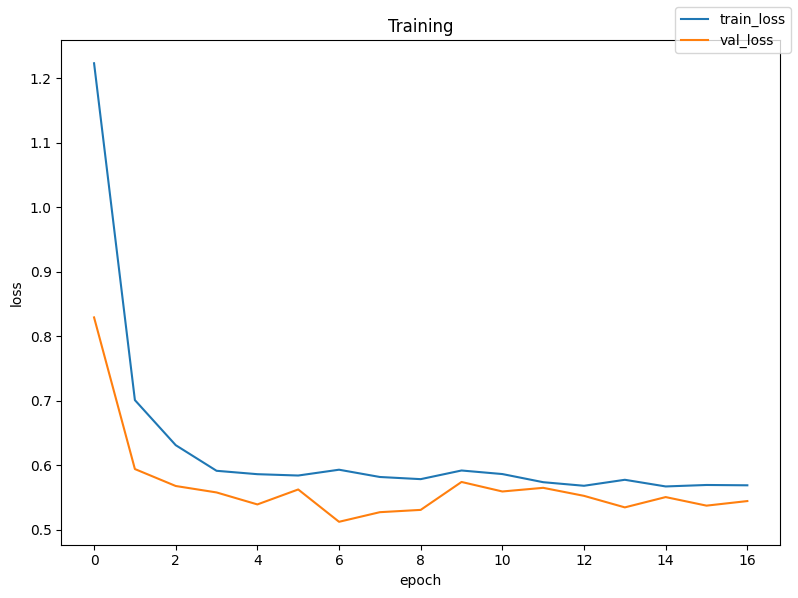

In [52]:
n_epochs = np.arange(0, len(train_result["train_loss"]))

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(n_epochs, train_result["train_loss"], label="train_loss")
ax.plot(n_epochs, train_result["val_loss"], label="val_loss")
# ax.set_xticks(n_epochs)

ax.set_title("Training")
ax.set_ylabel("loss")
ax.set_xlabel("epoch")
fig.legend()

plt.tight_layout()
plt.show()